# Multimodal Fusion — Deteksi Promosi Judi Online
**Arsitektur:** ResNet34 (frozen) + IndoBERT (frozen) → Self-Attention Fusion → FC → Softmax
**Late Fusion:** Prediction_V + Prediction_T + Prediction_F → weighted sum (grid search)

## 1. Import Library

In [4]:
import os
import ast
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from transformers import (
    AutoTokenizer,
    AutoModel
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print('Library siap.')

Library siap.


## 2. Cek GPU

In [5]:
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

CUDA available: True
GPU: Tesla T4
VRAM: 15.64 GB
Device: cuda


## 3. Path Dataset & Model

In [6]:
# ── PATH METADATA CSV ──
META_PATH   = '/kaggle/input/datasets/ricky131/dataset-indobert'
train_path  = os.path.join(META_PATH, 'train_balanced_metadata.csv')
val_path    = os.path.join(META_PATH, 'val_pure_metadata.csv')
test_path   = os.path.join(META_PATH, 'test_pure_metadata.csv')

# ── PATH GAMBAR ──
# Disesuaikan dengan path yang dipakai saat training ResNet34
IMAGE_ROOT  = '/kaggle/input/datasets/ricky131/image-resnet34-dataset-final/Dataset_Image'
IMAGE_DIR   = {
    0: os.path.join(IMAGE_ROOT, '0'),
    1: os.path.join(IMAGE_ROOT, '1')
}

# ── PATH MODEL PRETRAINED ──
MODEL_PATH      = '/kaggle/input/datasets/ricky131/model-pretrained'
RESNET_PATH     = os.path.join(MODEL_PATH, 'best_resnet34.pth')
INDOBERT_PATH   = MODEL_PATH  # folder berisi config.json, model.safetensors, tokenizer

# ── OUTPUT ──
BEST_FUSION_PATH = 'best_fusion_model.pth'

# Verifikasi
print('=== VERIFIKASI PATH ===')
for name, path in [
    ('train CSV',     train_path),
    ('val CSV',       val_path),
    ('test CSV',      test_path),
    ('Image Dir 0',   IMAGE_DIR[0]),
    ('Image Dir 1',   IMAGE_DIR[1]),
    ('ResNet34 .pth', RESNET_PATH),
    ('IndoBERT dir',  INDOBERT_PATH),
]:
    exists = os.path.exists(path)
    print(f'  {name:<18}: {"OK" if exists else "NOT FOUND"} — {path}')


=== VERIFIKASI PATH ===
  train CSV         : OK — /kaggle/input/datasets/ricky131/dataset-indobert/train_balanced_metadata.csv
  val CSV           : OK — /kaggle/input/datasets/ricky131/dataset-indobert/val_pure_metadata.csv
  test CSV          : OK — /kaggle/input/datasets/ricky131/dataset-indobert/test_pure_metadata.csv
  Image Dir 0       : OK — /kaggle/input/datasets/ricky131/image-resnet34-dataset-final/Dataset_Image/0
  Image Dir 1       : OK — /kaggle/input/datasets/ricky131/image-resnet34-dataset-final/Dataset_Image/1
  ResNet34 .pth     : OK — /kaggle/input/datasets/ricky131/model-pretrained/best_resnet34.pth
  IndoBERT dir      : OK — /kaggle/input/datasets/ricky131/model-pretrained


## 4. Load Dataset & Tampilkan Sampel

In [7]:
COLS = ['url', 'label', 'images', 'data_clean']

train_df = pd.read_csv(train_path, usecols=COLS)
val_df   = pd.read_csv(val_path,   usecols=COLS)
test_df  = pd.read_csv(test_path,  usecols=COLS)

# Drop NaN
for df in [train_df, val_df, test_df]:
    df.dropna(subset=['label', 'data_clean', 'images'], inplace=True)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

LABEL_NAMES = {0: 'Non Judol', 1: 'Judol'}

print(f'Train : {len(train_df)} data')
print(f'Val   : {len(val_df)} data')
print(f'Test  : {len(test_df)} data')
print(f'\nKolom: {list(train_df.columns)}')
print(f'\nContoh baris pertama:')
print(train_df.iloc[0])

Train : 3000 data
Val   : 278 data
Test  : 600 data

Kolom: ['url', 'label', 'images', 'data_clean']

Contoh baris pertama:
url           https://www.cnbcindonesia.com/news/20230324145...
label                                                         0
images                                    img_1779067955244.jpg
data_clean    anthony albanese, pm australia yang menangis g...
Name: 0, dtype: object


In [8]:
def get_first_image(images_val):
    raw = str(images_val).strip()

    # Coba parse sebagai Python list dulu: "['a.png', 'b.png']"
    try:
        parsed = ast.literal_eval(raw)
        if isinstance(parsed, list) and len(parsed) > 0:
            return str(parsed[0]).strip()
    except:
        pass

    # Format "a.png, b.png, c.png" atau "[a.png, b.png]"
    raw = raw.strip('[]')
    first = raw.split(',')[0].strip()
    first = first.strip("'\"")
    return first

def get_image_path(row):
    label_dir = IMAGE_DIR[int(row['label'])]
    return os.path.join(label_dir, row['image_name'])

# Terapkan ke semua split
train_df['image_name'] = train_df['images'].apply(get_first_image)
val_df['image_name']   = val_df['images'].apply(get_first_image)
test_df['image_name']  = test_df['images'].apply(get_first_image)

train_df['image_path'] = train_df.apply(get_image_path, axis=1)
val_df['image_path']   = val_df.apply(get_image_path, axis=1)
test_df['image_path']  = test_df.apply(get_image_path, axis=1)

# Validasi
for split_name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    exist = df['image_path'].apply(os.path.exists).sum()
    print(f'{split_name}: {exist}/{len(df)} gambar ditemukan')

# Cek sample hasilnya
print('\nSample image_name setelah fix:')
print(train_df['image_name'].head(5).tolist())

Train: 3000/3000 gambar ditemukan
Val: 278/278 gambar ditemukan
Test: 600/600 gambar ditemukan

Sample image_name setelah fix:
['img_1779067955244.jpg', 'e1eaa96a1dc92e620046df29e2d32808.jpg', '19.jpeg', 'img_1779068033817.jpg', 'img_new_1779071604570.jpg']


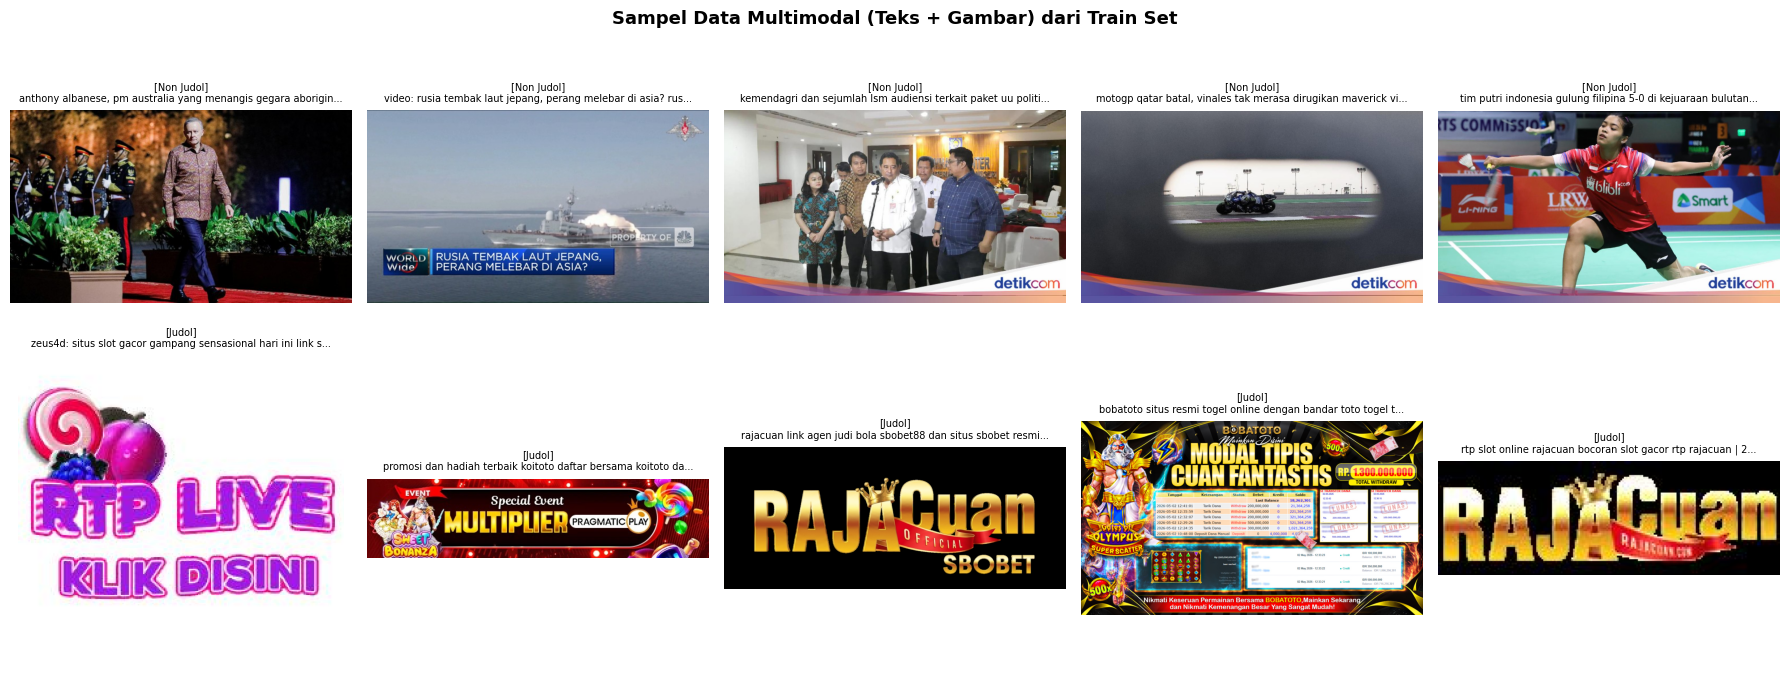

In [9]:
# Tampilkan 5 sampel per label (teks + gambar)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for row_idx, label in enumerate([0, 1]):
    samples = train_df[train_df['label'] == label].head(5)
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        ax = axes[row_idx][col_idx]
        try:
            img = Image.open(row['image_path']).convert('RGB')
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, 'IMG\nNOT FOUND', ha='center', va='center', transform=ax.transAxes)
        teks_pendek = str(row['data_clean'])[:60].replace('\n', ' ')
        ax.set_title(f'[{LABEL_NAMES[label]}]\n{teks_pendek}...', fontsize=7)
        ax.axis('off')

plt.suptitle('Sampel Data Multimodal (Teks + Gambar) dari Train Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Distribusi Dataset Per Label dan Per Split

Split         Non Judol (0)    Judol (1)    Total
--------------------------------------------------
Train                  1500         1500     3000
Validation              200           78      278
Test                    300          300      600


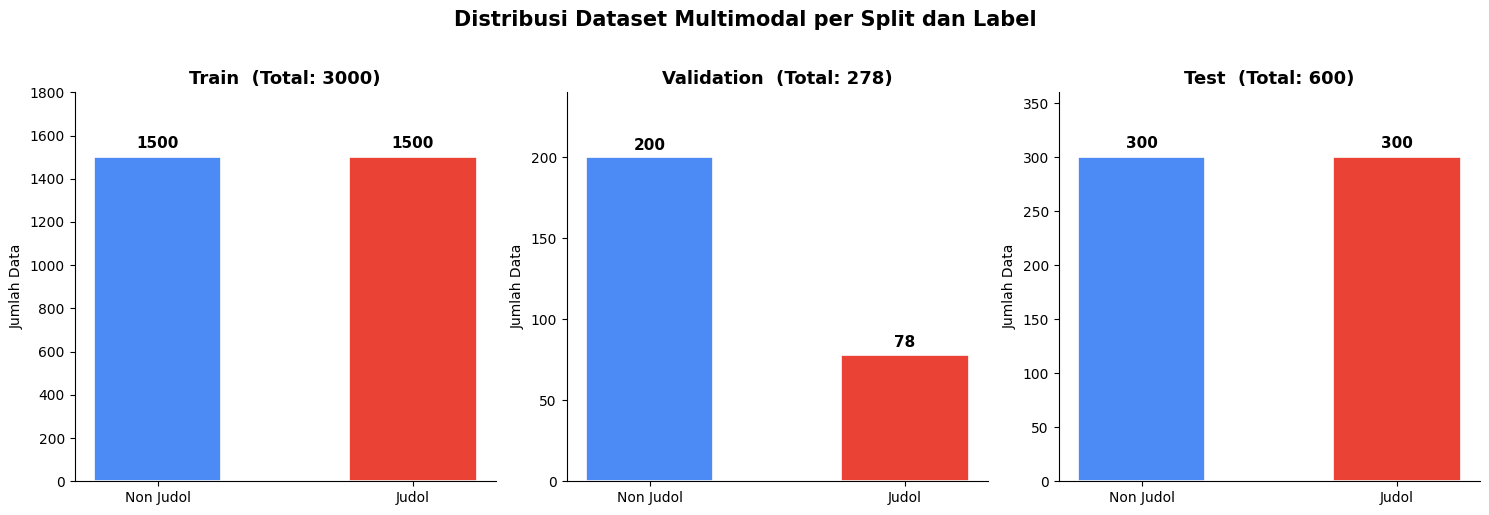

In [10]:
splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}

print(f"{'Split':<12} {'Non Judol (0)':>14} {'Judol (1)':>12} {'Total':>8}")
print('-' * 50)

summary = {}
for split_name, df in splits.items():
    counts = df['label'].value_counts()
    n0     = int(counts.get(0, 0))
    n1     = int(counts.get(1, 0))
    total  = n0 + n1
    summary[split_name] = {'Non Judol': n0, 'Judol': n1, 'Total': total}
    print(f"{split_name:<12} {n0:>14} {n1:>12} {total:>8}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4C8BF5', '#EA4335']

for ax, (split_name, counts) in zip(axes, summary.items()):
    bars = ax.bar(
        ['Non Judol', 'Judol'],
        [counts['Non Judol'], counts['Judol']],
        color=colors, edgecolor='white', linewidth=1.2, width=0.5
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts['Total'] * 0.01,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )
    ax.set_title(f'{split_name}  (Total: {counts["Total"]})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Jumlah Data')
    ax.set_ylim(0, max(counts['Non Judol'], counts['Judol']) * 1.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribusi Dataset Multimodal per Split dan Label', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Konfigurasi

In [11]:
# ── HYPERPARAMETER ──
MAX_LEN          = 512
BATCH_SIZE       = 16
EPOCHS           = 20
LR               = 1e-4
WEIGHT_DECAY     = 1e-3   # sama dengan training ResNet34 (AdamW weight_decay=1e-3)
DROPOUT          = 0.4    # sama dengan FC ResNet34 (Dropout(0.4))
ES_PATIENCE      = 3      # sama dengan training ResNet34

# ── DIMENSI FITUR ──
VISUAL_DIM    = 512   # output ResNet34 avg pool
TEXT_DIM      = 768   # output IndoBERT [CLS]
FUSION_DIM    = VISUAL_DIM + TEXT_DIM  # 1280
HIDDEN_DIM    = 256
NUM_CLASSES   = 2

print(f'Visual dim   : {VISUAL_DIM}')
print(f'Text dim     : {TEXT_DIM}')
print(f'Fusion dim   : {FUSION_DIM}')
print(f'Hidden dim   : {HIDDEN_DIM}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Epochs       : {EPOCHS}')
print(f'LR           : {LR}')
print(f'Weight Decay : {WEIGHT_DECAY}')
print(f'Dropout      : {DROPOUT}')
print(f'ES Patience  : {ES_PATIENCE}')


Visual dim   : 512
Text dim     : 768
Fusion dim   : 1280
Hidden dim   : 256
Batch size   : 16
Epochs       : 20
LR           : 0.0001
Weight Decay : 0.001
Dropout      : 0.4
ES Patience  : 3


## 7. Transform Gambar & Tokenizer Teks

In [12]:
# Transform gambar — TANPA augmentasi (frozen backbone, cukup normalize)
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Tokenizer IndoBERT
tokenizer = AutoTokenizer.from_pretrained(INDOBERT_PATH)

print('Transform gambar siap.')
print('Tokenizer IndoBERT siap.')

Transform gambar siap.
Tokenizer IndoBERT siap.


## 8. Multimodal Dataset Class

In [13]:
class MultimodalDataset(Dataset):

    def __init__(self, df, tokenizer, image_transform, max_len):
        self.texts           = df['data_clean'].astype(str).tolist()
        self.image_paths     = df['image_path'].tolist()
        self.labels          = df['label'].astype(int).tolist()
        self.tokenizer       = tokenizer
        self.image_transform = image_transform
        self.max_len         = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # ── TEKS ──
        text     = self.texts[idx]
        encoding = self.tokenizer(
            text,
            max_length    = self.max_len,
            truncation    = True,
            padding       = 'max_length',
            return_tensors= 'pt'
        )
        input_ids      = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        # ── GAMBAR ──
        img_path = self.image_paths[idx]
        try:
            img = Image.open(img_path).convert('RGB')
            img = self.image_transform(img)
        except:
            # Kalau gambar tidak ditemukan → tensor kosong (zeros)
            img = torch.zeros(3, 224, 224)

        # ── LABEL ──
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return {
            'input_ids'     : input_ids,
            'attention_mask': attention_mask,
            'image'         : img,
            'label'         : label
        }


train_dataset = MultimodalDataset(train_df, tokenizer, image_transform, MAX_LEN)
val_dataset   = MultimodalDataset(val_df,   tokenizer, image_transform, MAX_LEN)
test_dataset  = MultimodalDataset(test_df,  tokenizer, image_transform, MAX_LEN)

print(f'Train dataset : {len(train_dataset)} sampel')
print(f'Val dataset   : {len(val_dataset)} sampel')
print(f'Test dataset  : {len(test_dataset)} sampel')

Train dataset : 3000 sampel
Val dataset   : 278 sampel
Test dataset  : 600 sampel


## 9. DataLoader

In [14]:
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 188
Val batches   : 18
Test batches  : 38


## 10. Load Backbone ResNet34 (Frozen)

In [15]:
# Load ResNet34 dengan arsitektur PERSIS sama seperti saat training solo
resnet_backbone = models.resnet34(weights=None)

# PENTING: FC layer harus identik dengan yang dipakai saat training
# (Sequential: Dropout(0.4) -> Linear(512, 2))
num_features = resnet_backbone.fc.in_features
resnet_backbone.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, 2)
)

# Load bobot hasil training — state_dict akan match sempurna
resnet_backbone.load_state_dict(
    torch.load(RESNET_PATH, map_location=device)
)

# Hapus FC layer terakhir — hanya pakai sebagai feature extractor (avg pool output)
resnet_backbone.fc = nn.Identity()

# Freeze semua layer
for param in resnet_backbone.parameters():
    param.requires_grad = False

resnet_backbone = resnet_backbone.to(device)
resnet_backbone.eval()

# Verifikasi output dimensi
dummy_img    = torch.zeros(1, 3, 224, 224).to(device)
dummy_output = resnet_backbone(dummy_img)
print(f'ResNet34 output shape : {dummy_output.shape}')  # harusnya [1, 512]
print('ResNet34 backbone siap (frozen).')


ResNet34 output shape : torch.Size([1, 512])
ResNet34 backbone siap (frozen).


## 11. Load Backbone IndoBERT (Frozen)

In [16]:
# ── Load IndoBERT backbone dengan konfigurasi PERSIS sama seperti saat training ──
# Saat training pakai AutoModelForSequenceClassification dengan:
#   hidden_dropout_prob=0.1, attention_probs_dropout_prob=0.1
#   id2label={0:'Negatif', 1:'Positif'}, label2id={'Negatif':0, 'Positif':1}
# Di sini kita load sebagai AutoModel (base) untuk ekstrak [CLS] → fitur 768-dim
# lalu manual set dropout agar identik

from transformers import BertConfig, AutoModel, AutoModelForSequenceClassification

# Load config dari folder model, lalu override dropout agar identik dengan training
indobert_config = BertConfig.from_pretrained(
    INDOBERT_PATH,
    hidden_dropout_prob             = 0.1,
    attention_probs_dropout_prob    = 0.1,
    id2label                        = {0: 'Negatif', 1: 'Positif'},
    label2id                        = {'Negatif': 0, 'Positif': 1},
)

# Load base BERT (tanpa classification head) untuk ekstraksi fitur [CLS]
# — bobot encoder identik dengan model yang sudah di-fine-tune
indobert_backbone = AutoModel.from_pretrained(
    INDOBERT_PATH,
    config          = indobert_config,
    ignore_mismatched_sizes = True,   # abaikan mismatch classifier head
)

# Freeze semua layer
for param in indobert_backbone.parameters():
    param.requires_grad = False

indobert_backbone = indobert_backbone.to(device)
indobert_backbone.eval()

# Verifikasi output dimensi [CLS] token
dummy_ids  = torch.zeros(1, 10, dtype=torch.long).to(device)
dummy_mask = torch.ones(1, 10, dtype=torch.long).to(device)
with torch.no_grad():
    dummy_out = indobert_backbone(input_ids=dummy_ids, attention_mask=dummy_mask)
    cls_out   = dummy_out.last_hidden_state[:, 0, :]
print(f'IndoBERT [CLS] output shape : {cls_out.shape}')  # harusnya [1, 768]
print(f'  hidden_dropout             : {indobert_config.hidden_dropout_prob}')
print(f'  attention_dropout          : {indobert_config.attention_probs_dropout_prob}')
print('IndoBERT backbone siap (frozen) — konfigurasi identik dengan training.')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/datasets/ricky131/model-pretrained
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


IndoBERT [CLS] output shape : torch.Size([1, 768])
  hidden_dropout             : 0.1
  attention_dropout          : 0.1
IndoBERT backbone siap (frozen) — konfigurasi identik dengan training.


## 12. Fusion Model — Self-Attention

In [17]:
class SelfAttentionFusionClassifier(nn.Module):
    """
    Arsitektur Self-Attention Fusion:
    1. Project visual [512] dan text [768] ke ruang dimensi sama (proj_dim)
    2. Stack → sequence [2, proj_dim]
    3. Self-Attention (nn.MultiheadAttention) → attended features
    4. Mean-pool attended features → [proj_dim]
    5. FC → classifier (proj_dim → hidden_dim → num_classes)

    Kenapa self-attention?
    - Biarkan model belajar *seberapa penting* tiap modalitas secara dinamis
    - Tiap sampel punya bobot attention berbeda (adaptif)
    - Lebih ekspresif dibanding concat+FC biasa
    """

    def __init__(self, visual_dim, text_dim, proj_dim, hidden_dim,
                 num_classes, dropout, num_heads=4):
        super(SelfAttentionFusionClassifier, self).__init__()

        # ── Projection: bawa ke dimensi yang sama ──────────────────────────────
        self.proj_visual = nn.Sequential(
            nn.Linear(visual_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(),
        )
        self.proj_text = nn.Sequential(
            nn.Linear(text_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(),
        )

        # ── Self-Attention ──────────────────────────────────────────────────────
        # Input shape ke MHA: (seq_len, batch, embed_dim) = (2, B, proj_dim)
        self.self_attn = nn.MultiheadAttention(
            embed_dim   = proj_dim,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = False,   # pakai (seq, batch, dim)
        )
        self.attn_norm = nn.LayerNorm(proj_dim)

        # ── Classifier head ────────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, visual_feat, text_feat):
        # Project ke proj_dim
        v = self.proj_visual(visual_feat)   # [B, proj_dim]
        t = self.proj_text(text_feat)       # [B, proj_dim]

        # Stack jadi sequence [2, B, proj_dim]
        seq = torch.stack([v, t], dim=0)    # (seq=2, B, proj_dim)

        # Self-Attention: tiap modalitas attend ke modalitas lain & dirinya
        attn_out, attn_weights = self.self_attn(seq, seq, seq)
        # attn_out shape: (2, B, proj_dim)

        # Residual + norm
        attn_out = self.attn_norm(attn_out + seq)  # (2, B, proj_dim)

        # Mean-pool across sequence (rata-rata 2 modalitas)
        fused = attn_out.mean(dim=0)        # [B, proj_dim]

        # Classify
        logits = self.classifier(fused)     # [B, num_classes]
        return logits, attn_weights         # kembalikan attn_weights untuk analisis


# ── Hyperparameter tambahan ────────────────────────────────────────────────────
PROJ_DIM   = 512    # dimensi proyeksi bersama (≥ HIDDEN_DIM)
NUM_HEADS  = 4      # harus bisa membagi PROJ_DIM habis (512/4=128 ✓)

fusion_model = SelfAttentionFusionClassifier(
    visual_dim  = VISUAL_DIM,
    text_dim    = TEXT_DIM,
    proj_dim    = PROJ_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT,
    num_heads   = NUM_HEADS,
).to(device)

trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in fusion_model.parameters())
print(f'Self-Attention Fusion Model:')
print(f'  proj_dim      : {PROJ_DIM}')
print(f'  num_heads     : {NUM_HEADS}')
print(f'  Trainable     : {trainable:,} parameter')
print(f'  Total         : {total:,} parameter')
print('Fusion model (Self-Attention) siap.')


Self-Attention Fusion Model:
  proj_dim      : 512
  num_heads     : 4
  Trainable     : 1,841,922 parameter
  Total         : 1,841,922 parameter
Fusion model (Self-Attention) siap.


## 13. Loss, Optimizer, Scheduler

In [18]:
# label_smoothing=0.1 — konsisten dengan training ResNet34
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Hanya optimalkan parameter fusion_model (backbone frozen)
optimizer = optim.AdamW(
    fusion_model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode    = 'min',
    factor  = 0.5,
    patience= 2
)

best_val_f1 = 0.0
best_val_loss = float('inf')
es_counter    = 0

print('Setup selesai.')


Setup selesai.


## 14. Fungsi Ekstraksi Fitur

In [19]:
@torch.no_grad()
def extract_visual_features(images):
    """Ekstrak fitur visual dari ResNet34 backbone (frozen)."""
    resnet_backbone.eval()
    return resnet_backbone(images)  # [B, 512]

@torch.no_grad()
def extract_text_features(input_ids, attention_mask):
    """Ekstrak fitur teks [CLS] dari IndoBERT backbone (frozen)."""
    indobert_backbone.eval()
    outputs   = indobert_backbone(
        input_ids      = input_ids,
        attention_mask = attention_mask
    )
    cls_token = outputs.last_hidden_state[:, 0, :]  # [B, 768]
    return cls_token

print('Fungsi ekstraksi fitur siap.')


Fungsi ekstraksi fitur siap.


## 15. Training Loop

In [20]:
train_losses, val_losses         = [], []
train_accuracies, val_accuracies = [], []
train_f1s, val_f1s               = [], []

SEP = '=' * 55

for epoch in range(EPOCHS):

    print(f'\n{SEP}')
    print(f'Epoch {epoch+1}/{EPOCHS}')
    print(SEP)

    # ── TRAIN ──
    fusion_model.train()
    running_loss  = 0.0
    all_preds, all_labels = [], []

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images         = batch['image'].to(device)
        labels         = batch['label'].to(device)

        # Ekstrak fitur dari backbone (no_grad karena frozen)
        visual_feat = extract_visual_features(images)
        text_feat   = extract_text_features(input_ids, attention_mask)

        # Forward fusion
        optimizer.zero_grad()
        logits, _ = fusion_model(visual_feat, text_feat)  # (logits, attn_weights)
        loss   = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(logits, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc  = accuracy_score(all_labels, all_preds)
    train_f1   = f1_score(all_labels, all_preds, zero_division=0)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_f1s.append(train_f1)

    # ── VALIDATION ──
    fusion_model.eval()
    running_val_loss  = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images         = batch['image'].to(device)
            labels         = batch['label'].to(device)

            visual_feat = extract_visual_features(images)
            text_feat   = extract_text_features(input_ids, attention_mask)

            logits, _ = fusion_model(visual_feat, text_feat)  # (logits, attn_weights)
            loss   = criterion(logits, labels)

            running_val_loss += loss.item()
            _, preds = torch.max(logits, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = running_val_loss / len(val_loader)
    val_acc  = accuracy_score(val_labels, val_preds)
    val_f1   = f1_score(val_labels, val_preds, zero_division=0)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_f1s.append(val_f1)

    # ── PRINT ──
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Train Loss : {train_loss:.4f}  |  Train Acc : {train_acc:.4f}  |  Train F1 : {train_f1:.4f}')
    print(f'Val Loss   : {val_loss:.4f}  |  Val Acc   : {val_acc:.4f}  |  Val F1   : {val_f1:.4f}')
    print(f'LR         : {current_lr:.6f}')

    # ── SCHEDULER ──
    scheduler.step(val_loss)

    # ── SAVE BEST & EARLY STOPPING ──
    # Pakai val_f1 sebagai acuan utama; min_delta 1e-4 konsisten dengan training ResNet34
    if val_f1 > best_val_f1 + 1e-4:
        best_val_f1 = val_f1
        es_counter  = 0
        torch.save(fusion_model.state_dict(), BEST_FUSION_PATH)
        print(f'✅ Best model saved  (val_f1={best_val_f1:.4f})')
    else:
        es_counter += 1
        print(f'⏳ Early stopping: {es_counter}/{ES_PATIENCE}')
        if es_counter >= ES_PATIENCE:
            print('🛑 Early stopping triggered.')
            break

print('\nTraining selesai.')


Epoch 1/20
Train Loss : 0.2090  |  Train Acc : 0.9963  |  Train F1 : 0.9963
Val Loss   : 0.2258  |  Val Acc   : 0.9892  |  Val F1   : 0.9804
LR         : 0.000100
✅ Best model saved  (val_f1=0.9804)

Epoch 2/20
Train Loss : 0.2010  |  Train Acc : 1.0000  |  Train F1 : 1.0000
Val Loss   : 0.2301  |  Val Acc   : 0.9892  |  Val F1   : 0.9804
LR         : 0.000100
⏳ Early stopping: 1/3

Epoch 3/20
Train Loss : 0.2006  |  Train Acc : 1.0000  |  Train F1 : 1.0000
Val Loss   : 0.2279  |  Val Acc   : 0.9892  |  Val F1   : 0.9804
LR         : 0.000100
⏳ Early stopping: 2/3

Epoch 4/20
Train Loss : 0.2006  |  Train Acc : 1.0000  |  Train F1 : 1.0000
Val Loss   : 0.2289  |  Val Acc   : 0.9892  |  Val F1   : 0.9804
LR         : 0.000100
⏳ Early stopping: 3/3
🛑 Early stopping triggered.

Training selesai.


## 16. Plot Loss & Accuracy

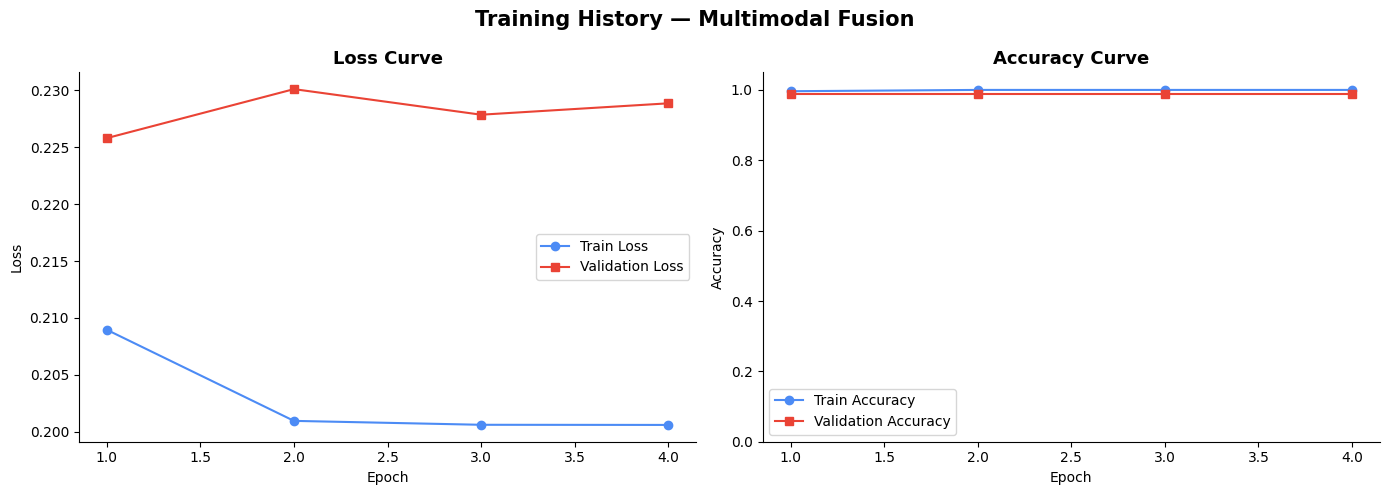

In [21]:
epochs_ran = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, train_losses, 'o-', label='Train Loss',      color='#4C8BF5')
axes[0].plot(epochs_ran, val_losses,   's-', label='Validation Loss', color='#EA4335')
axes[0].set_title('Loss Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(epochs_ran, train_accuracies, 'o-', label='Train Accuracy',      color='#4C8BF5')
axes[1].plot(epochs_ran, val_accuracies,   's-', label='Validation Accuracy', color='#EA4335')
axes[1].set_title('Accuracy Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Training History — Multimodal Fusion', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Evaluasi Fusion Model pada Test Set (Prediction_F)

In [22]:
# Load best fusion model
fusion_model.load_state_dict(torch.load(BEST_FUSION_PATH, map_location=device))
fusion_model.eval()

all_preds_F, all_labels_F = [], []
all_probs_F               = []  # prob kelas 1 untuk ROC-AUC
all_conf_F                = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images         = batch['image'].to(device)
        labels         = batch['label'].to(device)

        visual_feat = extract_visual_features(images)
        text_feat   = extract_text_features(input_ids, attention_mask)

        logits, _   = fusion_model(visual_feat, text_feat)  # (logits, attn_weights)
        probs       = torch.softmax(logits, dim=1)
        conf, preds = torch.max(probs, 1)

        all_preds_F.extend(preds.cpu().numpy())
        all_labels_F.extend(labels.cpu().numpy())
        all_probs_F.extend(probs[:, 1].cpu().numpy())
        all_conf_F.extend(conf.cpu().numpy())

acc_F  = accuracy_score(all_labels_F,  all_preds_F)
prec_F = precision_score(all_labels_F, all_preds_F, zero_division=0)
rec_F  = recall_score(all_labels_F,    all_preds_F, zero_division=0)
f1_F   = f1_score(all_labels_F,        all_preds_F, zero_division=0)
auc_F  = roc_auc_score(all_labels_F,   all_probs_F)

print('\n=== TEST RESULT — Fusion Model (Prediction_F) ===')
print(f'Accuracy  : {acc_F:.4f}')
print(f'Precision : {prec_F:.4f}')
print(f'Recall    : {rec_F:.4f}')
print(f'F1 Score  : {f1_F:.4f}')
print(f'ROC-AUC   : {auc_F:.4f}')
print(f'Total test: {len(all_preds_F)} sampel')


=== TEST RESULT — Fusion Model (Prediction_F) ===
Accuracy  : 0.9883
Precision : 0.9867
Recall    : 0.9900
F1 Score  : 0.9884
ROC-AUC   : 0.9966
Total test: 600 sampel


In [23]:
import os
print(os.path.exists(BEST_FUSION_PATH))
print(os.path.abspath(BEST_FUSION_PATH))

True
/kaggle/working/best_fusion_model.pth


## 18. Classification Report & Confusion Matrix — Fusion

              precision    recall  f1-score   support

   Non Judol       0.99      0.99      0.99       300
       Judol       0.99      0.99      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



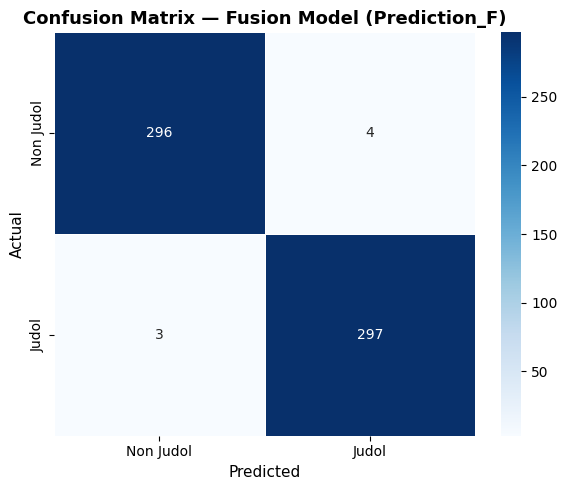

In [24]:
print(classification_report(
    all_labels_F, all_preds_F,
    target_names=['Non Judol', 'Judol']
))

cm = confusion_matrix(all_labels_F, all_preds_F)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non Judol', 'Judol'],
    yticklabels=['Non Judol', 'Judol'],
    linewidths=0.5, linecolor='white'
)
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual',    fontsize=11)
plt.title('Confusion Matrix — Fusion Model (Prediction_F)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 18b. Visualisasi Attention Weights — Self-Attention Fusion

## 19. Late Fusion — Kumpulkan Prediction_V dan Prediction_T

In [26]:
# Kumpulkan probabilitas dari ResNet34 solo (Prediction_V)
# dan IndoBERT solo (Prediction_T) pada test set

# ── PREDICTION_V (ResNet34 solo) ──
# Load ulang ResNet34 dengan FC persis sama seperti saat training
resnet_solo = models.resnet34(weights=None)
_num_feat   = resnet_solo.fc.in_features
resnet_solo.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(_num_feat, 2)
)
resnet_solo.load_state_dict(torch.load(RESNET_PATH, map_location=device))
resnet_solo.eval().to(device)

all_probs_V  = []
all_labels_V = []

with torch.no_grad():
    for batch in test_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        logits = resnet_solo(images)
        probs  = torch.softmax(logits, dim=1)

        all_probs_V.extend(probs.cpu().numpy())
        all_labels_V.extend(labels.cpu().numpy())

all_probs_V  = np.array(all_probs_V)   # [N, 2]
all_labels_V = np.array(all_labels_V)

print(f'Prediction_V terkumpul: {len(all_probs_V)} sampel')


Prediction_V terkumpul: 600 sampel


In [27]:
# ── PREDICTION_T (IndoBERT solo) ──
# Load IndoBERT dengan classification head
from transformers import AutoModelForSequenceClassification

indobert_solo = AutoModelForSequenceClassification.from_pretrained(
    INDOBERT_PATH,
    num_labels                      = 2,
    hidden_dropout_prob             = 0.1,
    attention_probs_dropout_prob    = 0.1,
    id2label                        = {0: 'Negatif', 1: 'Positif'},
    label2id                        = {'Negatif': 0, 'Positif': 1},
    ignore_mismatched_sizes         = True,
)
indobert_solo.eval().to(device)

all_probs_T  = []
all_labels_T = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = indobert_solo(
            input_ids      = input_ids,
            attention_mask = attention_mask
        )
        probs = torch.softmax(outputs.logits, dim=1)

        all_probs_T.extend(probs.cpu().numpy())
        all_labels_T.extend(labels.cpu().numpy())

all_probs_T  = np.array(all_probs_T)   # [N, 2]
all_labels_T = np.array(all_labels_T)

print(f'Prediction_T terkumpul: {len(all_probs_T)} sampel')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Prediction_T terkumpul: 600 sampel


In [28]:
# ── PREDICTION_F sudah ada dari cell 17 ──
all_probs_F_arr = np.array(list(zip(1 - np.array(all_probs_F), all_probs_F)))  # [N, 2]
all_labels_arr  = np.array(all_labels_F)

print(f'Prediction_F shape : {all_probs_F_arr.shape}')
print(f'Label shape        : {all_labels_arr.shape}')

Prediction_F shape : (600, 2)
Label shape        : (600,)


## 20. Grid Search — Cari α Optimal di Val Set

In [30]:
# ── BAGIAN 1: KUMPULKAN PROBABILITAS DARI VAL SET (JANGAN DIHAPUS) ──
val_probs_V, val_probs_T, val_probs_F = [], [], []
val_labels_gs = []

fusion_model.eval()

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images         = batch['image'].to(device)
        labels         = batch['label'].to(device)

        # Prediction_V
        logits_V = resnet_solo(images)
        probs_V  = torch.softmax(logits_V, dim=1)

        # Prediction_T
        out_T    = indobert_solo(input_ids=input_ids, attention_mask=attention_mask)
        probs_T  = torch.softmax(out_T.logits, dim=1)

        # Prediction_F
        vis_feat = extract_visual_features(images)
        txt_feat = extract_text_features(input_ids, attention_mask)
        logits_F, _ = fusion_model(vis_feat, txt_feat)
        probs_F  = torch.softmax(logits_F, dim=1)

        val_probs_V.extend(probs_V.cpu().numpy())
        val_probs_T.extend(probs_T.cpu().numpy())
        val_probs_F.extend(probs_F.cpu().numpy())
        val_labels_gs.extend(labels.cpu().numpy())

val_probs_V   = np.array(val_probs_V)
val_probs_T   = np.array(val_probs_T)
val_probs_F   = np.array(val_probs_F)
val_labels_gs = np.array(val_labels_gs)

print(f'Val prob terkumpul: {len(val_labels_gs)} sampel')

# ── BAGIAN 2: GRID SEARCH FINE-GRAINED (step=0.01) ──
best_f1     = 0.0
best_alpha  = (0.33, 0.33, 0.34)
step        = 0.01
results_gs  = []
for a1 in np.arange(0.0, 1.001, step):
    for a2 in np.arange(0.0, 1.001 - a1, step):
        a3 = round(1.0 - a1 - a2, 4)
        if a3 < 0 or a3 > 1:
            continue
        combined = a1 * val_probs_V + a2 * val_probs_T + a3 * val_probs_F
        preds    = np.argmax(combined, axis=1)
        score    = f1_score(val_labels_gs, preds, zero_division=0)
        results_gs.append((round(a1,2), round(a2,2), a3, score))
        if score > best_f1:
            best_f1    = score
            best_alpha = (round(a1,2), round(a2,2), a3)

print(f'Grid search selesai! (total kombinasi: {len(results_gs)})')
print(f'Best alpha : α1(Image)={best_alpha[0]:.2f}, α2(Text)={best_alpha[1]:.2f}, α3(Fusion)={best_alpha[2]:.2f}')
print(f'Best F1 val: {best_f1:.4f}')

results_df = pd.DataFrame(results_gs, columns=['a1_image','a2_text','a3_fusion','f1'])
top10 = results_df.sort_values('f1', ascending=False).head(10)
print('\nTop 10 kombinasi alpha (cek apakah stabil / banyak yang mirip):')
print(top10.to_string(index=False))

Val prob terkumpul: 278 sampel
Grid search selesai! (total kombinasi: 5151)
Best alpha : α1(Image)=0.46, α2(Text)=0.00, α3(Fusion)=0.54
Best F1 val: 0.9870

Top 10 kombinasi alpha (cek apakah stabil / banyak yang mirip):
 a1_image  a2_text  a3_fusion       f1
     0.50     0.17       0.33 0.987013
     0.50     0.18       0.32 0.987013
     0.50     0.19       0.31 0.987013
     0.50     0.20       0.30 0.987013
     0.50     0.21       0.29 0.987013
     0.50     0.22       0.28 0.987013
     0.50     0.07       0.43 0.987013
     0.49     0.17       0.34 0.987013
     0.49     0.16       0.35 0.987013
     0.49     0.15       0.36 0.987013


In [31]:
#OPTUNA

# pip install optuna --break-system-packages  (kalau belum ada)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    a1 = trial.suggest_float('a1', 0.0, 1.0)
    a2 = trial.suggest_float('a2', 0.0, 1.0 - a1)
    a3 = 1.0 - a1 - a2

    combined = a1 * val_probs_V + a2 * val_probs_T + a3 * val_probs_F
    preds    = np.argmax(combined, axis=1)
    return f1_score(val_labels_gs, preds, zero_division=0)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=500)

a1_opt = study.best_params['a1']
a2_opt = study.best_params['a2']
a3_opt = 1.0 - a1_opt - a2_opt

print(f'Best alpha (Optuna): α1(Image)={a1_opt:.4f}, α2(Text)={a2_opt:.4f}, α3(Fusion)={a3_opt:.4f}')
print(f'Best F1 val: {study.best_value:.4f}')

Best alpha (Optuna): α1(Image)=0.5180, α2(Text)=0.3576, α3(Fusion)=0.1244
Best F1 val: 0.9870


## 21. Late Fusion — Evaluasi Final di Test Set

In [32]:
# ── Evaluasi pakai alpha dari GRID SEARCH fine-grained ──
a1, a2, a3 = best_alpha
combined_probs = a1 * all_probs_V + a2 * all_probs_T + a3 * all_probs_F_arr
final_preds    = np.argmax(combined_probs, axis=1)
final_probs_1  = combined_probs[:, 1]

acc_late  = accuracy_score(all_labels_arr,  final_preds)
prec_late = precision_score(all_labels_arr, final_preds, zero_division=0)
rec_late  = recall_score(all_labels_arr,    final_preds, zero_division=0)
f1_late   = f1_score(all_labels_arr,        final_preds, zero_division=0)
auc_late  = roc_auc_score(all_labels_arr,   final_probs_1)

print("=== HASIL DENGAN ALPHA GRID SEARCH FINE (step=0.01) ===")
print(f'Alpha     : α1(Image)={a1:.2f}, α2(Text)={a2:.2f}, α3(Fusion)={a3:.2f}')
print(f'Accuracy  : {acc_late:.4f}')
print(f'Precision : {prec_late:.4f}')
print(f'Recall    : {rec_late:.4f}')
print(f'F1 Score  : {f1_late:.4f}')
print(f'ROC-AUC   : {auc_late:.4f}')
print(f'Total test: {len(final_preds)} sampel')

# ── Evaluasi pakai alpha dari OPTUNA ──
combined_probs_opt = a1_opt * all_probs_V + a2_opt * all_probs_T + a3_opt * all_probs_F_arr
final_preds_opt     = np.argmax(combined_probs_opt, axis=1)
final_probs_1_opt   = combined_probs_opt[:, 1]

acc_late_opt  = accuracy_score(all_labels_arr,  final_preds_opt)
prec_late_opt = precision_score(all_labels_arr, final_preds_opt, zero_division=0)
rec_late_opt  = recall_score(all_labels_arr,    final_preds_opt, zero_division=0)
f1_late_opt   = f1_score(all_labels_arr,        final_preds_opt, zero_division=0)
auc_late_opt  = roc_auc_score(all_labels_arr,   final_probs_1_opt)

print("\n=== HASIL DENGAN ALPHA OPTUNA ===")
print(f'Alpha     : α1(Image)={a1_opt:.4f}, α2(Text)={a2_opt:.4f}, α3(Fusion)={a3_opt:.4f}')
print(f'Accuracy  : {acc_late_opt:.4f}')
print(f'Precision : {prec_late_opt:.4f}')
print(f'Recall    : {rec_late_opt:.4f}')
print(f'F1 Score  : {f1_late_opt:.4f}')
print(f'ROC-AUC   : {auc_late_opt:.4f}')
print(f'Total test: {len(final_preds_opt)} sampel')

=== HASIL DENGAN ALPHA GRID SEARCH FINE (step=0.01) ===
Alpha     : α1(Image)=0.46, α2(Text)=0.00, α3(Fusion)=0.54
Accuracy  : 0.9900
Precision : 0.9868
Recall    : 0.9933
F1 Score  : 0.9900
ROC-AUC   : 0.9958
Total test: 600 sampel

=== HASIL DENGAN ALPHA OPTUNA ===
Alpha     : α1(Image)=0.5180, α2(Text)=0.3576, α3(Fusion)=0.1244
Accuracy  : 0.9867
Precision : 0.9867
Recall    : 0.9867
F1 Score  : 0.9867
ROC-AUC   : 0.9957
Total test: 600 sampel


## 22. Classification Report & Confusion Matrix — Late Fusion

              precision    recall  f1-score   support

   Non Judol       0.99      0.99      0.99       300
       Judol       0.99      0.99      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



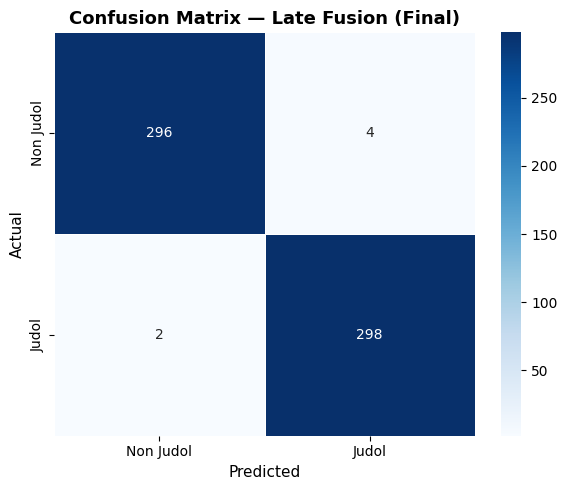

In [33]:
print(classification_report(
    all_labels_arr, final_preds,
    target_names=['Non Judol', 'Judol']
))

cm_late = confusion_matrix(all_labels_arr, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_late, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non Judol', 'Judol'],
    yticklabels=['Non Judol', 'Judol'],
    linewidths=0.5, linecolor='white'
)
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual',    fontsize=11)
plt.title('Confusion Matrix — Late Fusion (Final)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 23. ROC Curve — Perbandingan Semua Metode

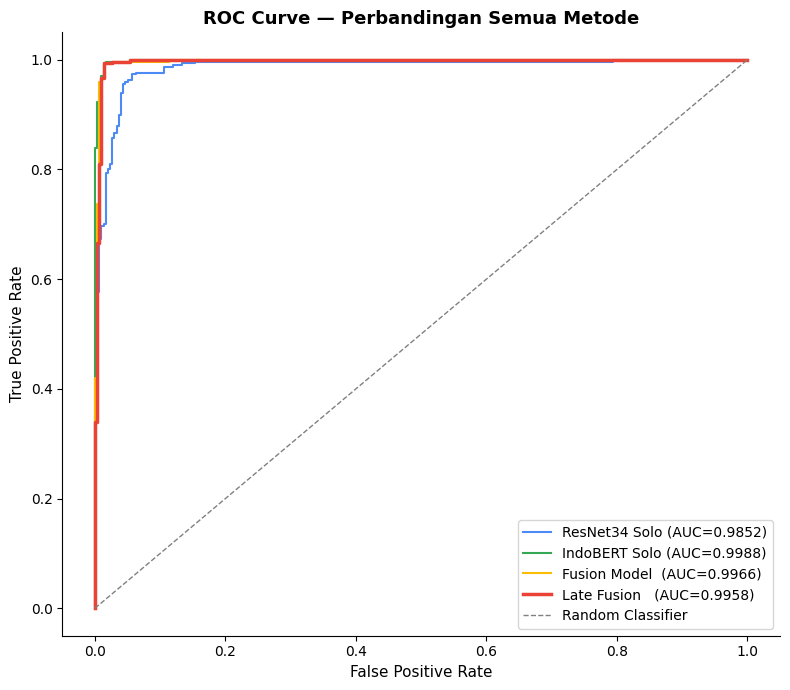

In [34]:
plt.figure(figsize=(8, 7))

# ResNet34 solo
fpr_V, tpr_V, _ = roc_curve(all_labels_V, all_probs_V[:, 1])
auc_V = roc_auc_score(all_labels_V, all_probs_V[:, 1])
plt.plot(fpr_V, tpr_V, label=f'ResNet34 Solo (AUC={auc_V:.4f})', color='#4C8BF5')

# IndoBERT solo
fpr_T, tpr_T, _ = roc_curve(all_labels_T, all_probs_T[:, 1])
auc_T = roc_auc_score(all_labels_T, all_probs_T[:, 1])
plt.plot(fpr_T, tpr_T, label=f'IndoBERT Solo (AUC={auc_T:.4f})', color='#34A853')

# Fusion model
fpr_F, tpr_F, _ = roc_curve(all_labels_F, all_probs_F)
plt.plot(fpr_F, tpr_F, label=f'Fusion Model  (AUC={auc_F:.4f})', color='#FBBC04')

# Late Fusion
fpr_L, tpr_L, _ = roc_curve(all_labels_arr, final_probs_1)
plt.plot(fpr_L, tpr_L, label=f'Late Fusion   (AUC={auc_late:.4f})', color='#EA4335', linewidth=2.5)

plt.plot([0, 1], [0, 1], 'gray', linestyle='--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate',  fontsize=11)
plt.title('ROC Curve — Perbandingan Semua Metode', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 24. Tabel Perbandingan Semua Metode

In [35]:
# Hitung metrik ResNet34 solo dan IndoBERT solo
preds_V = np.argmax(all_probs_V, axis=1)
preds_T = np.argmax(all_probs_T, axis=1)

results_table = pd.DataFrame([
    {
        'Metode'   : 'ResNet34 (Image Solo)',
        'Accuracy' : round(accuracy_score(all_labels_V, preds_V), 4),
        'Precision': round(precision_score(all_labels_V, preds_V, zero_division=0), 4),
        'Recall'   : round(recall_score(all_labels_V, preds_V, zero_division=0), 4),
        'F1 Score' : round(f1_score(all_labels_V, preds_V, zero_division=0), 4),
        'ROC-AUC'  : round(auc_V, 4),
    },
    {
        'Metode'   : 'IndoBERT (Text Solo)',
        'Accuracy' : round(accuracy_score(all_labels_T, preds_T), 4),
        'Precision': round(precision_score(all_labels_T, preds_T, zero_division=0), 4),
        'Recall'   : round(recall_score(all_labels_T, preds_T, zero_division=0), 4),
        'F1 Score' : round(f1_score(all_labels_T, preds_T, zero_division=0), 4),
        'ROC-AUC'  : round(auc_T, 4),
    },
    {
        'Metode'   : 'Multimodal Fusion (Self-Attention)',
        'Accuracy' : round(acc_F, 4),
        'Precision': round(prec_F, 4),
        'Recall'   : round(rec_F, 4),
        'F1 Score' : round(f1_F, 4),
        'ROC-AUC'  : round(auc_F, 4),
    },
    {
        'Metode'   : 'Late Fusion (Final)',
        'Accuracy' : round(acc_late, 4),
        'Precision': round(prec_late, 4),
        'Recall'   : round(rec_late, 4),
        'F1 Score' : round(f1_late, 4),
        'ROC-AUC'  : round(auc_late, 4),
    },
])

print('=== TABEL PERBANDINGAN SEMUA METODE ===')
print(results_table.to_string(index=False))

results_table.to_csv('comparison_results.csv', index=False)
print('\nDisimpan ke comparison_results.csv')

=== TABEL PERBANDINGAN SEMUA METODE ===
                            Metode  Accuracy  Precision  Recall  F1 Score  ROC-AUC
             ResNet34 (Image Solo)    0.9567     0.9567  0.9567    0.9567   0.9852
              IndoBERT (Text Solo)    0.9883     0.9867  0.9900    0.9884   0.9988
Multimodal Fusion (Self-Attention)    0.9883     0.9867  0.9900    0.9884   0.9966
               Late Fusion (Final)    0.9900     0.9868  0.9933    0.9900   0.9958

Disimpan ke comparison_results.csv


## 25. Simpan Model Fusion Final

In [36]:
import os
import json
import shutil

# ── Buat folder output ────────────────────────────────────────────────────────
OUTPUT_FOLDER = 'fusion_output'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ── Simpan fusion model (load best dulu untuk keamanan) ───────────────────────
fusion_model.load_state_dict(torch.load(BEST_FUSION_PATH, map_location=device))
fusion_model.eval()
torch.save(fusion_model.state_dict(), os.path.join(OUTPUT_FOLDER, 'best_fusion_model.pth'))

# ── Simpan alpha terbaik ──────────────────────────────────────────────────────
alpha_config = {
    'alpha_image'    : float(best_alpha[0]),
    'alpha_text'     : float(best_alpha[1]),
    'alpha_fusion'   : float(best_alpha[2]),
    'best_val_f1'    : float(best_f1),
    'test_f1'        : float(f1_late),
    'test_accuracy'  : float(acc_late),
    'test_roc_auc'   : float(auc_late)
}
with open(os.path.join(OUTPUT_FOLDER, 'late_fusion_alpha.json'), 'w') as f:
    json.dump(alpha_config, f, indent=2)

# ── Copy comparison_results.csv (sudah dibuat di cell sebelumnya) ─────────────
if os.path.exists('comparison_results.csv'):
    shutil.copy('comparison_results.csv', os.path.join(OUTPUT_FOLDER, 'comparison_results.csv'))
else:
    print('⚠️  comparison_results.csv belum ada — jalankan cell tabel perbandingan dulu')

# ── Verifikasi isi folder ─────────────────────────────────────────────────────
print(f'📁 Isi folder {OUTPUT_FOLDER}/:')
for fname in sorted(os.listdir(OUTPUT_FOLDER)):
    fpath = os.path.join(OUTPUT_FOLDER, fname)
    size  = os.path.getsize(fpath) / 1e6
    print(f'   {fname:<30} {size:.2f} MB')

print(f'\n✅ Semua file tersimpan di folder: {OUTPUT_FOLDER}/')
print('Download via: Right Sidebar → Output → fusion_output → Download as zip')

📁 Isi folder fusion_output/:
   best_fusion_model.pth          7.37 MB
   comparison_results.csv         0.00 MB
   late_fusion_alpha.json         0.00 MB

✅ Semua file tersimpan di folder: fusion_output/
Download via: Right Sidebar → Output → fusion_output → Download as zip


In [37]:
# ── ANALISIS ERROR CASE — Late Fusion ──
# Cari index sampel yang salah diprediksi oleh Late Fusion
wrong_idx = np.where(final_preds != all_labels_arr)[0]

print(f'Total sampel salah prediksi (Late Fusion): {len(wrong_idx)} dari {len(all_labels_arr)}')
print(f'Index sampel yang salah: {wrong_idx.tolist()}')

# Ambil detail masing-masing sampel yang salah:
# perlu row asli dari test_df untuk lihat teks & gambar
error_records = []

for idx in wrong_idx:
    row = test_df.iloc[idx]
    
    true_label = all_labels_arr[idx]
    pred_label = final_preds[idx]
    
    # probabilitas kelas 1 (Judol) dari masing-masing metode, untuk sampel ini
    prob_V = all_probs_V[idx][1]      # ResNet34 solo
    prob_T = all_probs_T[idx][1]      # IndoBERT solo
    prob_F = all_probs_F[idx]         # Fusion model (sudah 1D, prob kelas 1)
    prob_Late = final_probs_1[idx]    # Late Fusion final
    
    error_records.append({
        'idx'        : idx,
        'true_label' : LABEL_NAMES[true_label],
        'pred_label' : LABEL_NAMES[pred_label],
        'text'       : row['data_clean'][:100],  # potong biar gak kepanjangan
        'image_path' : row['image_path'],
        'prob_V(img)': round(prob_V, 4),
        'prob_T(text)': round(prob_T, 4),
        'prob_F(fusion)': round(prob_F, 4),
        'prob_Late'  : round(prob_Late, 4),
    })

error_df = pd.DataFrame(error_records)
print('\n=== DETAIL SAMPEL SALAH PREDIKSI ===')
print(error_df.to_string(index=False))

Total sampel salah prediksi (Late Fusion): 6 dari 600
Index sampel yang salah: [46, 94, 118, 184, 351, 594]

=== DETAIL SAMPEL SALAH PREDIKSI ===
 idx true_label pred_label                                                                                                 text                                                                                                        image_path  prob_V(img)  prob_T(text)  prob_F(fusion)  prob_Late
  46  Non Judol      Judol asia99 link alternatif login slot gacor rtp live 2026 butuh link alternatif asia99 terbaru? kami upd /kaggle/input/datasets/ricky131/image-resnet34-dataset-final/Dataset_Image/0/cb0a5d02c854372516e3a879b4464448.png       0.9172        0.9997          0.9565     0.9384
  94      Judol  Non Judol home posted february 20, 2026 | the over hundred pages of this presentation are a further example of /kaggle/input/datasets/ricky131/image-resnet34-dataset-final/Dataset_Image/1/2ef2719b967692482986fb98190e1ea0.png       0.4231        

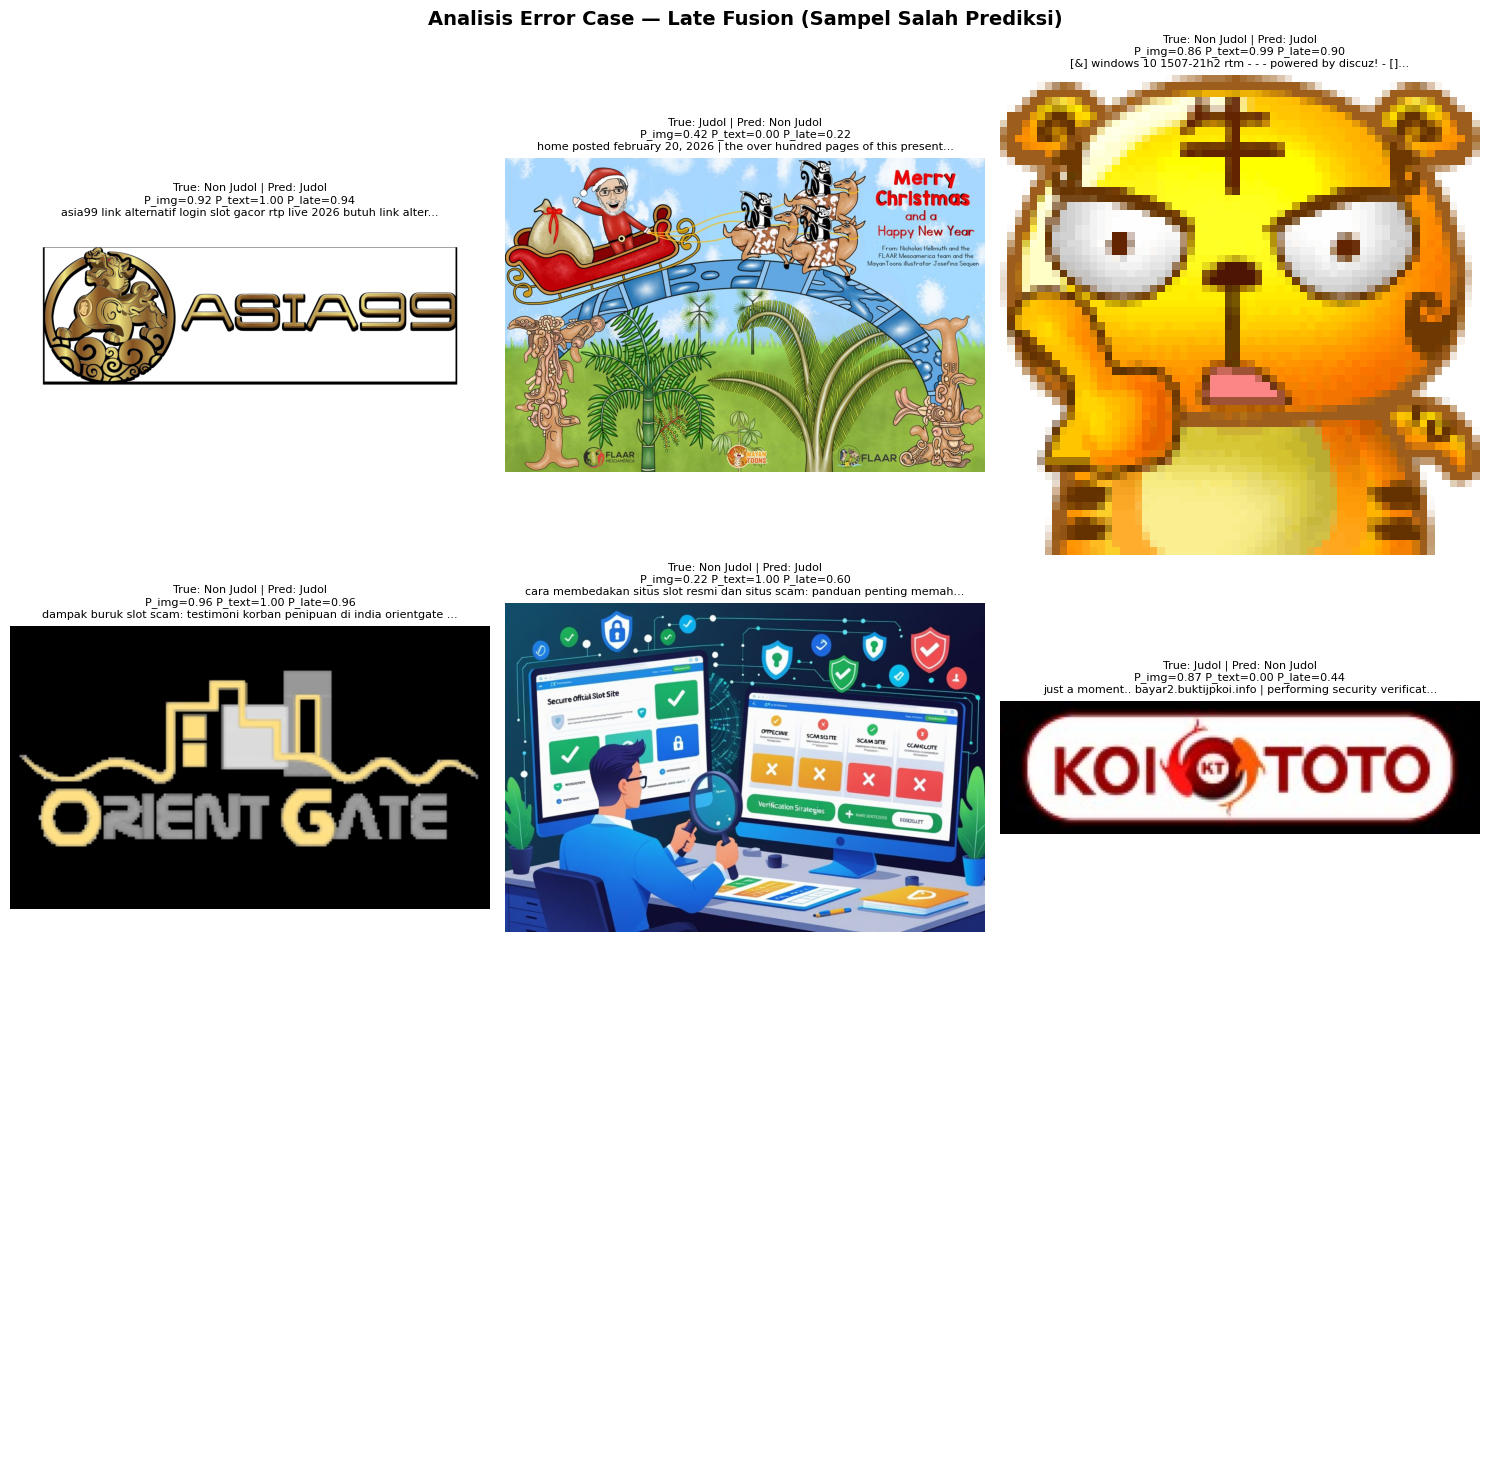

In [38]:
# ── VISUALISASI SAMPEL SALAH (teks + gambar) ──
n_show = min(9, len(wrong_idx))
show_idx = wrong_idx[:n_show]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, idx in enumerate(show_idx):
    row = test_df.iloc[idx]
    true_label = LABEL_NAMES[all_labels_arr[idx]]
    pred_label = LABEL_NAMES[final_preds[idx]]
    
    ax = axes[i]
    try:
        img = Image.open(row['image_path']).convert('RGB')
        ax.imshow(img)
    except:
        ax.text(0.5, 0.5, 'IMG NOT FOUND', ha='center', va='center', transform=ax.transAxes)
    
    teks_pendek = str(row['data_clean'])[:70].replace('\n', ' ')
    prob_V = all_probs_V[idx][1]
    prob_T = all_probs_T[idx][1]
    prob_Late = final_probs_1[idx]
    
    title = (f'True: {true_label} | Pred: {pred_label}\n'
              f'P_img={prob_V:.2f} P_text={prob_T:.2f} P_late={prob_Late:.2f}\n'
              f'{teks_pendek}...')
    ax.set_title(title, fontsize=8)
    ax.axis('off')

# kosongkan sisa subplot kalau error < 9
for j in range(len(show_idx), len(axes)):
    axes[j].axis('off')

plt.suptitle('Analisis Error Case — Late Fusion (Sampel Salah Prediksi)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
keywords = ['slot', 'gacor', 'rtp', 'scam', 'judi', 'togel', 'maxwin']
mask_has_keyword = train_df['data_clean'].str.contains('|'.join(keywords), case=False, na=False)

print(train_df[mask_has_keyword]['label'].value_counts())

label
1    1365
0      35
Name: count, dtype: int64
